In [1]:
import os
#import sys
#import pandas as pd
import yaml as yml
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
#import random
import seaborn as sns
from submapp import *
#from tools.tools_som import *
#from submapp.tools.data_processing import *
from tools.preprocessing.preprocessor import normalization

In [2]:
def transm_emi(HMM):
    """ To see transition and emission matrix """
    HMM_Tr = HMM.Tr
    HMM_Em = HMM.Em
    HMM_Tr_DS = downsample(HMM_Tr, 10)
    HMM_Em_DS = downsample(HMM_Em, 10)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(HMM_Tr, annot=False, cmap='Oranges', ax=axes[0])
    axes[0].set_title('Transition matrix')
    sns.heatmap(HMM_Em, annot=False, cmap='Oranges', ax=axes[1])
    axes[1].set_title('Emission matrix')
    plt.tight_layout()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(HMM_Tr_DS, annot=False, cmap='Oranges', ax=axes[0])
    axes[0].set_title('Transition matrix (low resolution)')
    sns.heatmap(HMM_Em_DS, annot=False, cmap='Oranges', ax=axes[1])
    axes[1].set_title('Emission matrix (low resolution)')
    plt.tight_layout()

In [3]:
import numpy as np

def downsample(arr, factor, mode='trim'):
    """
    Downsample 2D array by averaging non-overlapping blocks.

    Parameters
    ----------
    arr : array-like, shape (H, W)
        Input 2D array.
    factor : int
        Downsampling factor (block size). Result shape will be
        (H//factor, W//factor) for mode='trim' or
        (ceil(H/factor), ceil(W/factor)) for mode='pad'.
    mode : {'trim', 'pad'}
        'trim' - drop the right/bottom edges that don't fit exactly.
        'pad'  - pad the array with NaN so it fits evenly and use nanmean.

    Returns
    -------
    np.ndarray
        Downsampled 2D array (dtype=float).
    """
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError("arr must be 2D")
    if not (isinstance(factor, int) and factor > 0):
        raise ValueError("factor must be a positive integer")

    H, W = arr.shape

    if mode == 'trim':
        H_trim = (H // factor) * factor
        W_trim = (W // factor) * factor
        if H_trim == 0 or W_trim == 0:
            raise ValueError("factor is too large for 'trim' mode (no full blocks).")
        arr2 = arr[:H_trim, :W_trim]
        new_shape = (H_trim//factor, factor, W_trim//factor, factor)
        return arr2.reshape(new_shape).mean(axis=(1, 3))

    elif mode == 'pad':
        pad_H = (-H) % factor
        pad_W = (-W) % factor
        if pad_H or pad_W:
            arr_p = np.pad(arr, ((0, pad_H), (0, pad_W)),
                           mode='constant', constant_values=np.nan)
        else:
            arr_p = arr
        H2, W2 = arr_p.shape
        new_shape = (H2//factor, factor, W2//factor, factor)
        # use nanmean to ignore padded NaNs
        return np.nanmean(arr_p.reshape(new_shape), axis=(1, 3))

    else:
        raise ValueError("mode must be 'trim' or 'pad'")

In [4]:
# Function to apply training for both SOM 
def training_SOM(mySom, epochs_list, nb_blocks_train, input_train):
    print("------- Training for '{}' --------".format(mySom.name))
    print("------------------------------------------------")
    lr_initial_list, lr_final_list =  [1,1], [0.2,0.2] #Learning rate, default
    s_initial_list, s_final_list = [6,0.1], [1,0.001] #Radius of the neighbourhood function, default
    
    for training_step in range(len(lr_initial_list)):

        lr_initial = lr_initial_list[training_step]
        lr_final = lr_final_list[training_step]

        s_initial = s_initial_list[training_step]
        s_final = s_final_list[training_step]

        epochs = epochs_list[training_step]

        param = (lr_initial,lr_final,s_initial,s_final)
        T_train = len(np.concatenate(input_train))

        for e in range(epochs):
            print("#### Epoch : ", e, " ####")
            for y in range(nb_blocks_train):
                # Train the SOM with one more year from the training dataset 
                inputs = input_train[y]
                mySom.train(
                    data_train=inputs, 
                    param=param, 
                    T_train=T_train
                )

            # Hyperparameters can be updated after each epoch for a better control over the training
            lr_initial=lr_final
            lr_final=max(lr_final/1.2,0.01) # 0.01 limit value comes from common test on SOM, same for 1.2
            s_initial=s_final
            s_final=max(s_final/1.2,0.5) # 0.5 limit value comes from common test on SOM, same for 1.2
            # ----------------------------
            param = (lr_initial,lr_final,s_initial,s_final)
            
        print("------------------------------------------------")
        print("-------- Phase {} of training finished ---------".format(training_step+1))
        print("------------------------------------------------")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_vertical_timeseries(dates_num, series, labels, year, legends=None):
    """
    Plot multiple time series in vertically stacked subplots with formatted x-axis.

    Parameters:
    -----------
    dates_num : array-like
        Matplotlib date numbers (x-axis values).
    series : list of arrays
        List of 1D arrays to plot, one per subplot.
    labels : list of str
        List of y-axis labels (one per series).
    year : int
        Year used to generate x-ticks at Jan, Mar, May, Jul, Sep, Nov.
    """
    start = np.datetime64(f"{year}-01-01")  # start date
    end = np.datetime64(f"{year}-12-31")    # end date
    title = year
    
    fig, axes = plt.subplots(len(series), 1, figsize=(6.5, 6), sharex=True)

    if legends is None:
        for ax, y, label in zip(axes, series, labels):
            if y.shape[1] == 2:
                ax.plot(dates_num, y[:,0], label="obs")
                ax.plot(dates_num, y[:,1], label="est")
            else:
                ax.plot(dates_num, y, label="obs")
            ax.set_ylabel(label)
            ax.grid(True)
            ax.legend()
    else:
        for ax, y, label, legend in zip(axes, series, labels, legends):
            print(y.shape)
            if y.shape[1] == 2:
                ax.plot(dates_num, y[:,0], label=legends[0])
                ax.plot(dates_num, y[:,1], label=legends[1])
            else:
                ax.plot(dates_num, y, label=legends[0])
            ax.set_ylabel(label)
            ax.grid(True)
            ax.legend()
            
    # Format x-axis as dates
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    plt.xticks(rotation=45)
    axes[-1].set_xlabel('Date')

    # Set x-axis limits
    axes[0].set_xlim(mdates.date2num(start.astype('O')),
                     mdates.date2num(end.astype('O')))

    # Set x-ticks at Jan, Mar, May, Jul, Sep, Nov
    months = [1, 3, 5, 7, 9, 11]
    tick_dates_list = [np.datetime64(f"{year}-{m:02d}-01") for m in months]
    axes[-1].set_xticks(mdates.date2num(np.array(tick_dates_list).astype('O')))

    fig.suptitle(f"{year}", fontsize=14)
    
    plt.tight_layout()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_time_depth(var2D, dates_num, depth_levels, label, year, title=None):
    """
    Plot a 2D variable over time and depth using pcolormesh.

    Parameters:
    -----------
    var2D : 2D array
        Data array with shape (depth, time)
    dates_num : array-like
        Matplotlib date numbers (time axis)
    depth_levels : array-like
        Depth levels (y-axis)
    label : str
        Colorbar label
    year : str
        Year
    """
    if title is None:
        title = year
    else:
        title = f"{year} {title}"
    
    X, Y = np.meshgrid(dates_num, depth_levels)

    plt.figure(figsize=(8,3))
    pcm = plt.pcolormesh(X, Y, var2D, shading='auto', cmap='viridis')
    plt.colorbar(pcm, label=label)
    plt.gca().xaxis_date()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    plt.xticks(rotation=45)
    plt.xlabel('Date')
    plt.ylabel('Depth (m)')
    plt.tight_layout()
    plt.title(title)

In [7]:
def print_weights_surface(map_surf, surf_data, surf_var, surf_unit, idx_target=0):
# Visualization with projection on all variables couple
    for k in range(len(surf_var)):
        if k != idx_target:
            x_data = []
            y_data = []
            for i in range(len(surf_data[0][:])):
                x_data.append(surf_data[k][i].flatten())
                y_data.append(surf_data[idx_target][i].flatten())
            x_data = np.concatenate(x_data)
            y_data = np.concatenate(y_data)
        
            plt.figure(figsize=(6,6))
            sns.scatterplot(x=x_data, y=y_data,color='g',alpha=0.5, s = 50, label = 'Data')
            sns.scatterplot(x=map_surf.som.weights[:,k], y=map_surf.som.weights[:,idx_target],color='k',label = 'Referent vectors', s = 70)
            plt.xlabel(f"{surf_var[k]} [{surf_unit[k]}]")
            plt.ylabel(f"{surf_var[idx_target]} [{surf_unit[idx_target]}]")
            plt.title(f"Map deployment on training dataset {surf_var[idx_target]} vs {surf_var[k]}")
            plt.show()

In [8]:
import os

def save_config(surf_m, surf_n, prof_m, prof_n, initialization, iterations):
    # Save configuration to yaml file

    obj_dir = f"./objects/{name_experiment}"
    os.makedirs(obj_dir, exist_ok=True)

    # Create dictionary
    config = {
        "name_experiment": name_experiment,
        "surface_SOM": {
            "m": surf_m,
            "n": surf_n
        },
        "profile_SOM": {
            "m": prof_m,
            "n": prof_n
        },
        "initialization": initialization,
        "iterations": iterations
    }

    # Save to yaml
    file = f"{obj_dir}/config.yaml"
    with open(file, "w") as f:
        yml.dump(config, f, default_flow_style=False)
        
    print(f"{file} saved")

In [9]:
import numpy as np

def load_data_tutorial(path_data, path_yaml):
    # load surface and profile data from numpy or pickle
    
    data = np.load(path_data, allow_pickle=True)
    print(f"{path_data} loaded")
    info = load_yaml(path_yaml)
    print(f"{path_yaml} loaded")

    return data, info

In [10]:
import yaml as yml

def load_yaml(path_yaml):
    # Load meta data of training data from yaml file
    try:
        with open(path_yaml, "r") as file:
            info = yml.safe_load(file)
            file.close()
    except Exception as e:
        print("Error reading the config file")
        
    return info

In [11]:
def mod_training_SOM(dict_config,data_surf,info_surf,data_prof,info_prof,trial_id,isplot=False,issave=False):

    #--- SOM training module
    # 
    #  1. surface SOM
    #  2. profile SOM
    #

    #-- retrieve SOM configuration

    surf_n = dict_config['surf_n']
    surf_m = dict_config['surf_m']
    prof_n = dict_config['prof_n']
    prof_m = dict_config['prof_m']
    initialization = dict_config['initialization']

    #-- retrieve trainig data configuration

    surf_var = info_surf["variables"]
    surf_unit = info_surf["unit"]
    prof_var = info_prof["variables"]
    depth_levels = np.array(info_prof["depth"])
    blocks       = np.array(info_prof["blocks"])
    nb_blocks_train = len(blocks)

    #-- surface SOM

    # normalization
    surf_stats = normalization(nb_blocks_train, data_surf, len(surf_var))
    surf_train_norm = surf_stats[0]
    surf_data_mean = surf_stats[1].astype(np.float64)
    surf_data_stdev = surf_stats[2].astype(np.float64)

    # prepare SOM
    SOM_surf = som.Som(surf_n,surf_m,surf_var,len(surf_var),weights=None,name='som_surface',
                   data_mean=surf_data_mean, data_stdev=surf_data_stdev)

    # initialize SOM
    if initialization == "Gaussian":        
        SOM_surf.random_weights_initialization(distribution = "gaussian")
    elif initialization == "PCA":
        SOM_surf.pca_weights_initialization(np.concatenate(surf_train_norm))
    
    # training SOM
    training_SOM(mySom=SOM_surf, epochs_list= [4,4], nb_blocks_train=nb_blocks_train, input_train=surf_train_norm)

    # Creation of a map for surface dataset with its SOM
    map_surf = map2d.Map2d(som=SOM_surf,name="surf_train_mapped")
    map_surf.map_from_data(np.concatenate(surf_train_norm))

    #-- profile SOM

    # normalization
    norm_stats = normalization(nb_blocks_train, data_prof, len(prof_var))
    prof_train_norm = norm_stats[0]
    prof_data_mean = norm_stats[1].astype(np.float64)
    prof_data_stdev = norm_stats[2].astype(np.float64)

    # prepare SOM
    SOM_prof = som.Som(prof_n, prof_m, prof_var,len(depth_levels),weights=None,name='som_profile',
                   data_mean=prof_data_mean, data_stdev=prof_data_stdev)

    # initialize SOM
    if initialization == "Gaussian":
        SOM_prof.random_weights_initialization(distribution = "gaussian")
    
    elif initialization == "PCA":
        SOM_prof.pca_weights_initialization(np.concatenate(prof_train_norm))
    
    # training SOM
    training_SOM(mySom=SOM_prof, epochs_list= [6,6], nb_blocks_train= nb_blocks_train, input_train= prof_train_norm)

    # Creation of a map for profile dataset with its SOM
    map_prof = map2d.Map2d(som=SOM_prof,name="prof_train_mapped")
    map_prof.map_from_data(np.concatenate(prof_train_norm))

    #---- save SOM objects
    
    SOM_surf.clear_map_info()
    SOM_surf.map(np.concatenate(surf_train_norm))
    
    SOM_prof.clear_map_info()
    SOM_prof.map(np.concatenate(prof_train_norm))
    
    if issave:
        path = f"./objects/{trial_id}/Som/"

        # Save surface SOM
        som.save(SOM_surf, filename = "surf.pkl", path=path)
        print(f"{path}surf.pkl saved")

        # Save profile SOM
        som.save(SOM_prof, filename = "prof.pkl", path=path)
        print(f"{path}prof.pkl saved")
        
    else:
        SOM_surf._Som__clear_graph()
        SOM_prof._Som__clear_graph()

    if isplot:
        #-- Visualization of surface SOM
        print_weights_surface(map_surf, data_surf, surf_var, surf_unit,idx_target = 0)

        #-- Visualization of profile SOM (Projection on 2 main PCA axis)
        map_prof.som.print_weights_pca_axis(np.concatenate(prof_train_norm), True)
        
    return SOM_surf, SOM_prof, map_surf, map_prof

In [12]:
def mod_training_hmm(dict_config,map_surf,map_prof,trial_id,isplot=False,issave=False):
    #---- HMM training module
    #
    # The method init_model initializes the probabilities (elements of the matrices (Tr, Em, pi)) 
    # by counting the transitions and emission in the training dataset.
    
    #-- retrieve SOM configuration

    surf_n = dict_config['surf_n']
    surf_m = dict_config['surf_m']
    prof_n = dict_config['prof_n']
    prof_m = dict_config['prof_m']
    iterations = dict_config['iterations']
    
    #-- HMM creation and initialization

    myHMM = hmm.Hmm(surf_n*surf_m, prof_n* prof_m, name="hmm")
    myHMM.init_model(map_surf.classes, map_prof.classes, ln_eps = -50)
    myHMM.pi = np.ones((prof_n* prof_m))
    myHMM.pi = np.diag(myHMM.Tr) + 0.001

    #-- BW algorithm
    for i in range(iterations):
        if i == 0:
            print(" #################### BAUM-WELCH ##########################")
        myHMM.bw(np.concatenate([map_surf.classes]))
    
    if issave:
        #-- save HMM objects
        path = f"./objects/{trial_id}/Hmm/"

        # Save HMM
        hmm.save(myHMM, filename="hmm" ,path=path)
        print(f"{path}hmm.pkl saved")
    
    #--  check Hmm Tr/Em/Pi visually
    if isplot:
        # plot Tr and Em
        transm_emi(myHMM)
    
        # plot diag(Tr)
        diag = np.diag(myHMM.Tr)
        idx_max = np.argmax(diag)
        fig = plt.subplots(figsize=(8, 3))
        plt.plot(diag, marker='o', color='blue')
        plt.plot(idx_max, diag[idx_max], marker='o', color='red')
        plt.title("Diagonal component of HMM.Tr")
        plt.show()

        # plot Pi
        init_pi = myHMM.pi
        idx_max = np.argmax(init_pi)
        fig = plt.subplots(figsize=(8, 3))
        plt.plot(init_pi, marker='o', color='blue')
        plt.plot(idx_max, init_pi[idx_max], marker='o', color='red')
        plt.title("Initial profile probability: Pi")
        plt.show()
    
    return myHMM

In [41]:
def mod_prediction(data_surf,info_surf,data_prof,info_prof,SOM_prof,SOM_surf,myHMM,dict_dates,dict_years,isplot=False):
    #--- HMM-SOM prediction module
    #
    #
    blocks = info_prof["blocks"]
    nb_blocks = len(blocks)

    #-- Normalization

    # surface data
    surf_vars = info_surf["variables"]
    surf_unit = info_surf["unit"]
    surf_norm = normalization(nb_blocks, data_surf, len(surf_vars), new_data=True, 
                                data_stdev=SOM_surf.data_stdev, data_mean=SOM_surf.data_mean)
    if nb_blocks > 1:
        surf_norm = np.concatenate(surf_norm).astype('float64')

    # profile data
    prof_vars = info_prof["variables"]
    prof_unit = info_prof["unit"]
    prof_norm = normalization(nb_blocks, data_prof, len(prof_vars), new_data=True, 
                                data_stdev=SOM_prof.data_stdev, data_mean=SOM_prof.data_mean)
    if nb_blocks > 1:
        prof_norm = np.concatenate(prof_norm).astype('float64')

    #-- Construct expected (BMU) profiles

    # classification (find BMU)
    map_expected = map2d.Map2d(som=SOM_prof, name="map_expected")
    map_expected.map_from_data(prof_norm)

    #--- preprocess "new" surface data

    # classification (find BMU)
    map_surf = map2d.Map2d(som=SOM_surf, name='map_obs_infer')
    map_surf.map_from_data(surf_norm, overwrite=True)

    #--- Apply Virterbi alogirhtm to get a prediction.
    classes_estimated = myHMM.viterbi(map_surf.classes)

    # Construct a map based on the profile SOM already trained and classes given by Viterbi algorithm.
    map_estimated = map2d.Map2d(som=SOM_prof, name="map_estimation")
    map_estimated.map_from_classes(classes_estimated, overwrite=True)

    # save estimated profiles and plot figures
    label = f"{prof_vars[0]} [{prof_unit[0]}]"
    labels = info_surf["variables"]

    dict_profiles = {}

    for idx, block in enumerate(blocks):
        
        var2D_obs = data_prof[0,idx].T #-- read true profiles
        var2D_bmu = map_expected.values.T    #-- expected (BMU) profiles
        var2D_est = map_estimated.values.T   #-- estimated profiles

        dict_var2D = {
          'obs' : var2D_obs,
          'bmu' : var2D_bmu,
          'est' : var2D_est
        }
        
        dict_profiles[block] = dict_var2D
    
        if isplot:
            dates_num = dict_dates[block]
            year      = dict_years[block]

            series = data_surf_valid[:,idx]
            plot_vertical_timeseries(dates_num, series, labels, year)
    
            #-- estimated profiles    
            plot_time_depth(var2D_obs, dates_num, depth_levels, label, year, title='True')
            plot_time_depth(var2D_bmu, dates_num, depth_levels, label, year, title='BMU')
            plot_time_depth(var2D_est, dates_num, depth_levels, label, year, title='Estimated')
            
    return dict_profiles

In [14]:
# Surface input data
path_surf_data = "./SubMAPP_tutorial/tutorial_submapp/data/train_surf.npy"
path_surf_yaml = "./SubMAPP_tutorial/tutorial_submapp/data/info_surf_training.yml"

# Profile input data
path_prof_data = "./SubMAPP_tutorial/tutorial_submapp/data/train_prof.npy"
path_prof_yaml = "./SubMAPP_tutorial/tutorial_submapp/data/info_prof_training.yml"

# Surface true data
path_surf_data_valid = "./SubMAPP_tutorial/tutorial_submapp/data/infer_surf.npy"
path_surf_yaml_valid = "./SubMAPP_tutorial/tutorial_submapp/data/info_surf_prediction.yml"

# Profile true data
path_prof_data_valid = "./SubMAPP_tutorial/tutorial_submapp/data/truth_prof.npy"
path_prof_yaml_valid = "./SubMAPP_tutorial/tutorial_submapp/data/info_prof_prediction.yml"

In [15]:
# set boolean variables

isplot = False # plot figures
isrenew = True # renew SOM_surf, SOM_prof and myHMM

# Name of experiment
name_experiment = "test02"

# Size of surface SOM
surf_m, surf_n = 15, 15  # Ex default : 15, 15 

# Size of prfoile SOM
prof_m, prof_n = 6, 30 # Ex default : 6 ,30

# Initialization method
initialization = "Gaussian" # "Gaussian" or "PCA"

# BW algorithm interation number
iterations = 0

# Number of trials
nb_trial = 100

# Save configuration to yaml file
save_config(surf_m, surf_n, prof_m, prof_n, initialization, iterations)

# Save configuration to dictionary

dict_config = {
   "name_experiment" : name_experiment, 
   "surf_m" : surf_m, 
   "surf_n" : surf_n, 
   "prof_m" : prof_m, 
   "prof_n" : prof_n,
   "initialization" : initialization,
   "iterations" : iterations,
   "nb_trial" : nb_trial
}

for key, value in dict_config.items():
    print(f" {key}: {value}")

./objects/test02/config.yaml saved
 name_experiment: test02
 surf_m: 15
 surf_n: 15
 prof_m: 6
 prof_n: 30
 initialization: Gaussian
 iterations: 0
 nb_trial: 100


In [33]:
#-- load training data

data_surf, info_surf = load_data_tutorial(path_surf_data,path_surf_yaml)
data_prof, info_prof = load_data_tutorial(path_prof_data,path_prof_yaml)

print('----------')
print('info_surf:')
print('----------')
for key, value in info_surf.items():
    print(f" {key}: {value}")
print()

surf_vars_train = info_surf['variables']
surf_unit_train = info_surf['unit']

print('----------')
print('info_prof:')
print('----------')
for key, value in info_prof.items():
    print(f" {key}: {value}")
print()

#-- load validation data

data_surf_valid, info_surf_valid = load_data_tutorial(path_surf_data_valid,path_surf_yaml_valid)
data_prof_valid, info_prof_valid = load_data_tutorial(path_prof_data_valid,path_prof_yaml_valid)

print('----------------')
print('info_surf_valid:')
print('----------------')
for key, value in info_surf_valid.items():
    print(f" {key}: {value}")
print()

print('----------------')
print('info_prof_valid:')
print('----------------')
for key, value in info_prof_valid.items():
    print(f" {key}: {value}")
print()

#-- Construct dates (trianing)

print('----------------')
print('dates:')
print('----------------')

blocks = np.array(info_prof["blocks"])

dict_dates = {}
dict_years = {}

for block in blocks:
    year = block
    start = np.datetime64(f"{year}-01-01")  # start date
    end = np.datetime64(f"{year}-12-31")    # end date
    dates = np.arange(start, end + np.timedelta64(1, 'D'), np.timedelta64(5, 'D'))
    dates_num = mdates.date2num(dates.astype('O'))
    
    dict_dates[block] = dates_num
    dict_years[block] = year
print(dict_years)

#-- blocks
print('----------------')
print('blocks:')
print('----------------')
blocks = np.array(info_prof["blocks"])

print(blocks)

#-- Construct dates (validation)

print('----------------')
print('dates_valid:')
print('----------------')

blocks_valid = np.array(info_prof_valid["blocks"])

dict_dates_valid = {}
dict_years_valid = {}

for block in blocks_valid:
    year = block
    start = np.datetime64(f"{year}-01-01")  # start date
    end = np.datetime64(f"{year}-12-31")    # end date
    dates = np.arange(start, end + np.timedelta64(1, 'D'), np.timedelta64(5, 'D'))
    dates_num = mdates.date2num(dates.astype('O'))
    
    dict_dates_valid[block] = dates_num
    dict_years_valid[block] = year
print(dict_years_valid)
    
#-- blocks_valid
print('----------------')
print('blocks_valid:')
print('----------------')
blocks_valid = np.array(info_prof["blocks"])

print(blocks)

#-- Target surface variable

print('----------------')
print('target variable:')
print('----------------')

target_idx = 0
surf_vars = surf_vars_train
surf_unit = surf_unit_train

print(f"{surf_vars_train[target_idx]} [{surf_unit_train[target_idx]}]")

#-- Depth

print('----------------')
print('depth:')
print('----------------')
depth_levels = np.array(info_prof["depth"])

print(depth_levels)



./SubMAPP_tutorial/tutorial_submapp/data/train_surf.npy loaded
./SubMAPP_tutorial/tutorial_submapp/data/info_surf_training.yml loaded
./SubMAPP_tutorial/tutorial_submapp/data/train_prof.npy loaded
./SubMAPP_tutorial/tutorial_submapp/data/info_prof_training.yml loaded
----------
info_surf:
----------
 blocks: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
 data_origin: surface
 unit: ['log(mgChl/m3)', 'Celsius', 'W/m2', 'm']
 variables: ['log_chl-a', 'sst', 'I_0', 'mld_surf']

----------
info_prof:
----------
 blocks: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
 data_origin: profile
 depth: [-99.6304702758789, -94.77935028076172, -90.04602813720703, -85.4159927368164, -80.88153839111328, -76.44107818603516, -72.09835815429688, -67.86146545410156, -63.74198913574219, -59.75507736206055, -55.9201545715332, -52.255462646484375, -48.7726936340332, -45.47

In [17]:
if isplot:
    #--- Visual check of training data
    #
    #

    blocks = np.array(info_prof["blocks"])
    #years = blocks

    depth_levels = np.array(info_prof["depth"])
    prof_var = info_prof["variables"]
    prof_unit = info_prof["unit"]
    surf_var = info_surf["variables"]
    surf_unit = info_surf["unit"]      # not used

    label = f"{prof_var[target_idx]} [ {prof_unit[target_idx]} ]"

    for idx, block in enumerate(blocks):
        #year = block

        #-- time axis
        dates_num = dict_dates[block]
        year = dict_years[block]
    
        #-- plot vertically stacked surface data
        series = data_surf[:,idx]
        labels = surf_var
        plot_vertical_timeseries(dates_num, series, labels, year)
    
        #-- plot profile data
        var2D = data_prof[0,idx].T
        label = f"{prof_var[0]} [{prof_unit[0]}]"
        plot_time_depth(var2D, dates_num, depth_levels, label, year)

In [18]:
#----- trainig PROFHMM (SOM+HMM) in ensemble
#
#

obj_dir = f"./objects/{name_experiment}/profhmm"
file_path = f"{obj_dir}/dict_profhmm.pkl"
os.makedirs(obj_dir, exist_ok=True)

if not os.path.exists(file_path) or isrenew:
    dict_profhmm ={}

    for j in range(nb_trial):
        trial_id = f"{name_experiment}_{j:03d}"
        print('====================')
        print(f" {trial_id}")
        print('====================')
    
        #-- train SOM weights (referent vectors)
        SOM_surf, SOM_prof, map_surf, map_prof = mod_training_SOM(dict_config,data_surf,info_surf,data_prof,info_prof,trial_id,isplot)
    
        #-- train HMM matrices: Tr, EM and Pi
        myHMM = mod_training_hmm(dict_config,map_surf,map_prof,trial_id,isplot)
    
        #-- 
        dict_profhmm[trial_id] = {
           'SOM_surf': SOM_surf,
           'SOM_prof': SOM_prof,
           'myHMM': myHMM
        }
    
    with open(file_path, 'wb') as f:
        pickle.dump(dict_profhmm, f)
        print(f"{file_path} saved")
    
else:

    with open(file_path, 'rb') as f:
        dict_profhmm = pickle.load(f)
        print(f"{file_path} loaded")

 test02_000
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph i

#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
 test02_005
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
--------------------------------------------

------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
 test02_010
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph

#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
 test02_015
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#

------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
 test02_020
------- Training for 'som_surface' --------
-------------------------------------------

...

#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch : 

------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initializat

#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
#### Epoch :  4  ####
Graph initialization
#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------

 test02_093
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
------- Training for 'som_profile' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initializ

#### Epoch :  5  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
 test02_098
------- Training for 'som_surface' --------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 1 of training finished ---------
------------------------------------------------
#### Epoch :  0  ####
Graph initialization
#### Epoch :  1  ####
Graph initialization
#### Epoch :  2  ####
Graph initialization
#### Epoch :  3  ####
Graph initialization
------------------------------------------------
-------- Phase 2 of training finished ---------
------------------------------------------------
------- Training for 'som_profile' --------
--------------------------

 test02_000
Viterbi algorithm done in  0.01  sec, using  73  inputs


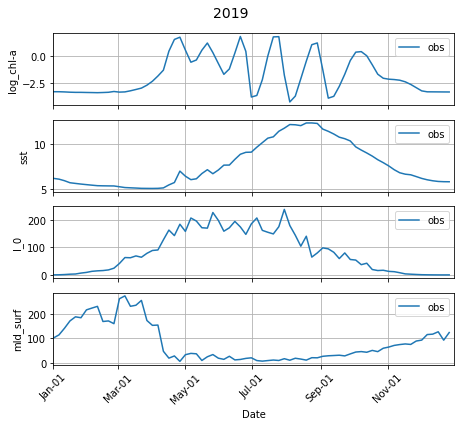

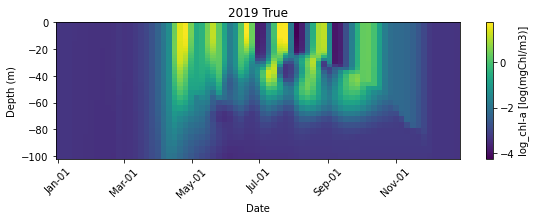

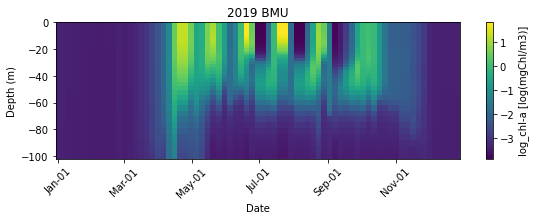

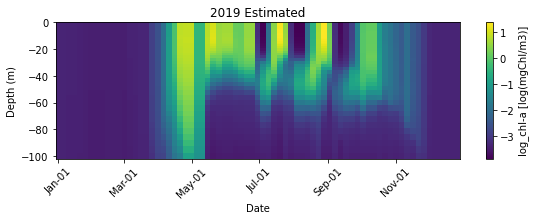

In [44]:
dict_dict_profiles = {}

for j in range(nb_trial):
    trial_id = f"{name_experiment}_{j:03d}"
    print('====================')
    print(f" {trial_id}")
    print('====================')
    
    # retrieve SOM and HMM information
    SOM_surf = dict_profhmm[trial_id]['SOM_surf']
    SOM_prof = dict_profhmm[trial_id]['SOM_prof']
    myHMM = dict_profhmm[trial_id]['myHMM']
    
    #-- test prediction with validation dataset
    dict_profiles = mod_prediction(data_surf_valid,info_surf_valid,data_prof_valid,info_prof_valid,SOM_prof,SOM_surf,myHMM,dict_dates_valid,dict_years_valid,isplot)
    
    #-- save predicted profile for error analysis
    dict_dict_profiles[trial_id] = dict_profiles

test02_000
  2019
   obs
   bmu
   est
corr: 0.9383587551275359
bias: -0.022707699718750946
std: 0.5536981258561477
mse: 0.3070972542031274


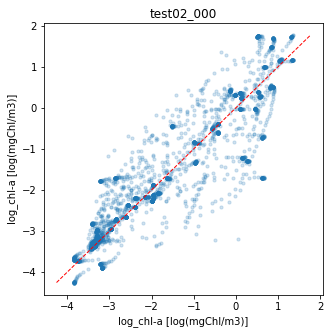

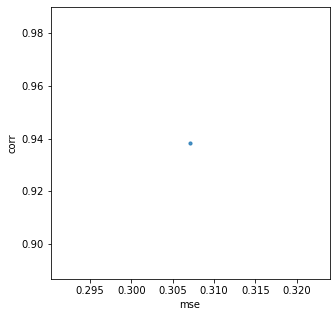

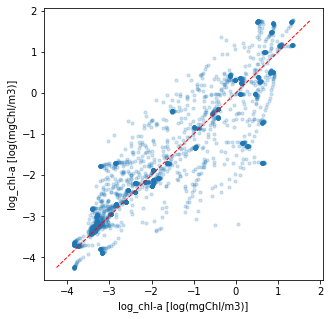

In [45]:
#--- prepare ensemble data set
#
#

prof_var = info_prof["variables"]
prof_unit = info_prof["unit"]

list_x = []
list_y = []
list_corr = []
list_mse = []

list_arr_var2D_est = []
list_arr_var2D_obs = []
list_arr_var2D_bmu = []

for key in dict_dict_profiles: # trial_id
    list_var2D_est = []
    list_var2D_obs = []
    list_var2D_bmu = []

    print(key)
    dict_profiles = dict_dict_profiles[key]
    for subkey in dict_profiles: # block
        print(" ",subkey)
        dict_var2D = dict_profiles[subkey]
        list_var2D_est.append(dict_var2D['est'])
        list_var2D_obs.append(dict_var2D['obs'])
        list_var2D_bmu.append(dict_var2D['bmu'])
        for subsubkey in dict_var2D:
            print("  ",subsubkey)
            
    arr_var2D_est = np.array(list_var2D_est)
    arr_var2D_obs = np.array(list_var2D_obs)
    arr_var2D_bmu = np.array(list_var2D_bmu)
    
    list_arr_var2D_est.append(arr_var2D_est)
    list_arr_var2D_obs.append(arr_var2D_obs)
    list_arr_var2D_bmu.append(arr_var2D_bmu)

    # flatten to 1D
    x = arr_var2D_est.ravel()
    y = arr_var2D_obs.ravel()
    diff = x - y

    # ensemble stats
    corr = np.corrcoef(x, y)[0, 1] # correlation (Pearson)
    bias = np.mean(diff)           # bias
    std = np.std(diff)             # standard deviation
    mse = np.mean(diff**2)         # mean square error
    print('corr:',corr)
    print('bias:',bias)
    print('std:',std)
    print('mse:',mse)
    
    list_x.append(x)
    list_y.append(y)
    list_corr.append(corr)
    list_mse.append(mse)

    if isplot:
        # scatter plot
        plt.figure(figsize=(5,5))
        plt.scatter(x, y, alpha=0.2, s=10)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        plt.plot(lims, lims, 'r--', linewidth=1)
        label = f"{prof_var[0]} [{prof_unit[0]}]"
        plt.xlabel(label)
        plt.ylabel(label)
        plt.title(trial_id)
    
ens_arr_var2D_est = np.array(list_arr_var2D_est)
ens_arr_var2D_obs = np.array(list_arr_var2D_obs)
ens_arr_var2D_bmu = np.array(list_arr_var2D_bmu)
    
x = np.array(list_x)
y = np.array(list_y)
corr = np.array(list_corr)
mse = np.array(list_mse)
    
if isplot:
    # scatter plot
    plt.figure(figsize=(5,5))
    plt.scatter(mse, corr, alpha=0.8, s=10)
    plt.xlabel('mse')
    plt.ylabel('corr')
    
    # scatter plot
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, alpha=0.2, s=10)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    plt.plot(lims, lims, 'r--', linewidth=1)
    label = f"{prof_var[0]} [{prof_unit[0]}]"
    plt.xlabel(label)
    plt.ylabel(label)

corr: 0.9659220739903313
bias: 0.009013417981020377
std: 0.408721733212456
mse: 0.16713469690389465
[17897. 17902. 17907. 17912. 17917. 17922. 17927. 17932. 17937. 17942.
 17947. 17952. 17957. 17962. 17967. 17972. 17977. 17982. 17987. 17992.
 17997. 18002. 18007. 18012. 18017. 18022. 18027. 18032. 18037. 18042.
 18047. 18052. 18057. 18062. 18067. 18072. 18077. 18082. 18087. 18092.
 18097. 18102. 18107. 18112. 18117. 18122. 18127. 18132. 18137. 18142.
 18147. 18152. 18157. 18162. 18167. 18172. 18177. 18182. 18187. 18192.
 18197. 18202. 18207. 18212. 18217. 18222. 18227. 18232. 18237. 18242.
 18247. 18252. 18257.] <class 'numpy.float64'>
[2019] (1,)


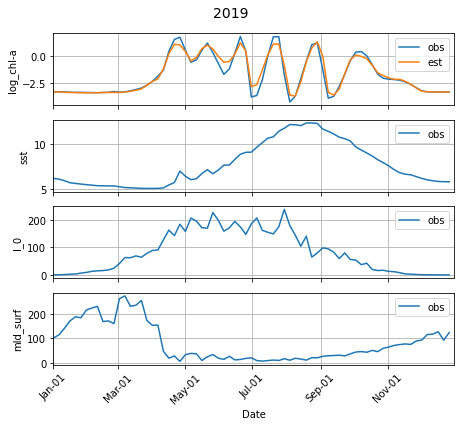

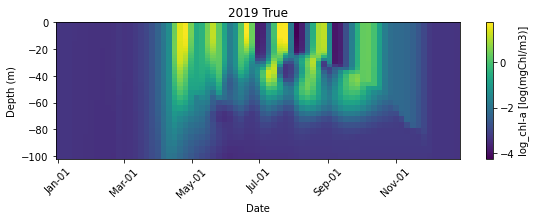

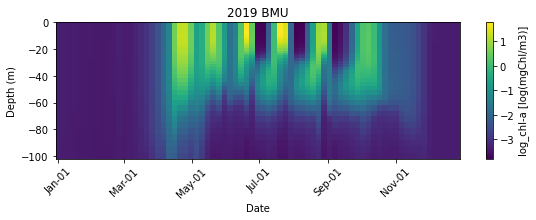

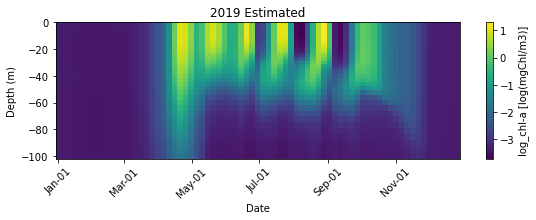

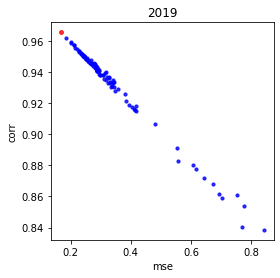

In [21]:
#--- Ensemble mean estimation
#
#

arr_var2D_est_ensmean = np.mean(ens_arr_var2D_est,axis=0)
arr_var2D_obs_ensmean = np.mean(ens_arr_var2D_obs,axis=0)
arr_var2D_bmu_ensmean = np.mean(ens_arr_var2D_bmu,axis=0)

#-- extract block information
blocks = np.array(info_prof_valid["blocks"])
years = blocks

#-- extract variable list
labels = info_surf["variables"]

#-- extract depth coordinate
depth_levels = np.array(info_prof["depth"])

#-- ectract target variable name [unit]
prof_vars = info_prof_valid["variables"]
prof_unit = info_prof_valid["unit"]

label = f"{prof_vars[target_idx]} [{prof_unit[target_idx]}]"

for idx, block in enumerate(blocks_valid):
    
    var2D_est = arr_var2D_est_ensmean[idx,:]
    var2D_obs = arr_var2D_obs_ensmean[idx,:]
    var2D_bmu = arr_var2D_bmu_ensmean[idx,:]
    
    dates_num = dict_dates_valid[block]
    year = dict_years_valid[block]
    
    # extract furface data
    series = data_surf_valid[:,idx]
    
    #-- replace target variable with [obs,est]
    var2D_obs_surf = var2D_obs[-1,:]
    var2D_est_surf = var2D_est[-1,:]
    series[target_idx] = np.column_stack((var2D_obs_surf,var2D_est_surf))

    plot_vertical_timeseries(dates_num, series, labels, block)
    
    #-- estimated profiles    
    plot_time_depth(var2D_obs, dates_num, depth_levels, label, block, title='True')
    plot_time_depth(var2D_bmu, dates_num, depth_levels, label, block, title='BMU')
    plot_time_depth(var2D_est, dates_num, depth_levels, label, block, title='Estimated')
    
    # flatten to 1D
    x = var2D_est.ravel()
    y = var2D_obs.ravel()
    diff = x - y

    # ensemble stats
    corr_ens = np.corrcoef(x, y)[0, 1] # correlation (Pearson)
    bias_ens = np.mean(diff)           # bias
    std_ens = np.std(diff)             # standard deviation
    mse_ens = np.mean(diff**2)         # mean square error
    print('corr:',corr_ens)
    print('bias:',bias_ens)
    print('std:',std_ens)
    print('mse:',mse_ens)
    
    # scatter plot
    plt.figure(figsize=(4,4))
    plt.scatter(mse, corr, alpha=0.8, s=10, c='b')
    plt.scatter(mse_ens, corr_ens, alpha=0.8, s=15, c='r')
    plt.xlabel('mse')
    plt.ylabel('corr')
    plt.title(block)

print(dates_num,type(dates_num[0]))
years = np.unique([mdates.num2date(d).year for d in dates_num])
print(years,years.shape)